# Alice - Fractional Factorial Analysis

Analysis of $2^{4-1}_{IV}$ fractional factorial experiment for the Alice dataset.

## Dataset Description
- **Source**: Custom-constructed controlled NLI benchmark
- **Size**: 20 hypothesis statements over a short document about "Alice"
- **Special Feature**: Contains modal language ("always", "usually", "rarely", "never")
- **Categories**: 4-way classification
  - **Entailment**: Direct entailment (e.g., "Alice attends a university")
  - **Contradiction**: Statements contradicting the source (e.g., "Alice studies a subject other than CS")
  - **Uncertain**: Uncertainty under incomplete information (e.g., "Alice passes all exams")
  - **Not Mentioned**: Statements outside source scope (e.g., "Alice has a dog")

## Experimental Factors
- **T1 (`use_openie`)**: OpenIE relation triples during text-to-logic conversion
- **T2 (`use_enrichment_kb`)**: KB enrichment (modal-pair, negation, finite-domain, conflict resolution)
- **Q1 (`use_shortcuts`)**: Deterministic shortcut detectors
- **Q2 (`expand_query`)**: Query expansion with synonym variants + majority voting

**Generator**: $T_2 = Q_1 \cdot Q_2 \cdot T_1$

**Note**: This is the only dataset where atomic propositions retain modal expressions.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Use seaborn style (compatible with older matplotlib)
try:
    plt.style.use('seaborn-whitegrid')
except:
    plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')

# Dataset-specific constants
DATASET_NAME = 'Alice'
CATEGORIES = ['entailment', 'contradiction', 'uncertain', 'not_mentioned']
FACTORS = ['Q1_shortcuts', 'Q2_expand', 'T1_openie', 'T2_enrich']
FACTOR_LABELS = ['Q1: Shortcuts', 'Q2: Expand', 'T1: OpenIE', 'T2: Enrich']

## 1. Experimental Design

In [2]:
# Define the 2^{4-1} fractional factorial design
design = pd.DataFrame({
    'Run': [1, 2, 3, 4, 5, 6, 7, 8],
    'Q1_shortcuts': [-1, +1, -1, +1, -1, +1, -1, +1],
    'Q2_expand': [-1, -1, +1, +1, -1, -1, +1, +1],
    'T1_openie': [-1, -1, -1, -1, +1, +1, +1, +1],
})
design['T2_enrich'] = design['Q1_shortcuts'] * design['Q2_expand'] * design['T1_openie']

print("Fractional Factorial Design (2^{4-1}_IV):")
print("="*55)
print("Run  Q1:Short  Q2:Expand  T1:OpenIE  T2:Enrich")
print("-"*55)
for _, row in design.iterrows():
    print(f" {int(row['Run']):1d}      {'+' if row['Q1_shortcuts']==1 else '-'}         {'+' if row['Q2_expand']==1 else '-'}          {'+' if row['T1_openie']==1 else '-'}          {'+' if row['T2_enrich']==1 else '-'}")

Fractional Factorial Design (2^{4-1}_IV):
Run  Q1:Short  Q2:Expand  T1:OpenIE  T2:Enrich
-------------------------------------------------------
 1      -         -          -          -
 2      +         -          -          +
 3      -         +          -          +
 4      +         +          -          -
 5      -         -          +          +
 6      +         -          +          -
 7      -         +          +          -
 8      +         +          +          +


## 2. Input Results

Enter accuracy values (0-1 or 0-100) for each run and category.

In [3]:
# ============================================================================
# INPUT ALICE RESULTS HERE
# ============================================================================
# Run configurations:
#   Run 1: Q1-, Q2-, T1-, T2-
#   Run 2: Q1+, Q2-, T1-, T2+
#   Run 3: Q1-, Q2+, T1-, T2+
#   Run 4: Q1+, Q2+, T1-, T2-
#   Run 5: Q1-, Q2-, T1+, T2+
#   Run 6: Q1+, Q2-, T1+, T2-
#   Run 7: Q1-, Q2+, T1+, T2-
#   Run 8: Q1+, Q2+, T1+, T2+
# ============================================================================

results = {
    'Run': [1, 2, 3, 4, 5, 6, 7, 8],
    'overall':        [0.6000, 0.7000, 0.6500, 0.6500, 0.6000, 0.6000, 0.6000, 0.6000],
    'entailment':     [0.8333, 0.8333, 0.6667, 0.8333, 0.6667, 0.6667, 0.6667, 0.6667],
    'contradiction':  [0.7500, 0.7500, 0.7500, 0.7500, 0.5000, 0.7500, 0.7500, 0.5000],
    'uncertain':      [0.8000, 1.0000, 1.0000, 0.8000, 1.0000, 0.8000, 0.8000, 1.0000],
    'not_mentioned':  [0.0000, 0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.2000],
}

In [4]:
# Process results
df = design.merge(pd.DataFrame(results), on='Run')

# Convert to 0-1 scale if needed
for col in ['overall'] + CATEGORIES:
    if df[col].max() > 1:
        df[col] = df[col] / 100.0

# Auto-compute overall if zeros
if df['overall'].sum() == 0 and df[CATEGORIES].sum().sum() > 0:
    df['overall'] = df[CATEGORIES].mean(axis=1)
    print("Auto-computed overall accuracy from category means")

print(f"\n{DATASET_NAME} Results:")
print(df[['Run', 'overall'] + CATEGORIES].to_string(index=False))


Alice Results:
 Run  overall  entailment  contradiction  uncertain  not_mentioned
   1     0.60      0.8333           0.75        0.8            0.0
   2     0.70      0.8333           0.75        1.0            0.2
   3     0.65      0.6667           0.75        1.0            0.2
   4     0.65      0.8333           0.75        0.8            0.2
   5     0.60      0.6667           0.50        1.0            0.2
   6     0.60      0.6667           0.75        0.8            0.2
   7     0.60      0.6667           0.75        0.8            0.2
   8     0.60      0.6667           0.50        1.0            0.2


## 3. Effect Computation

In [5]:
def compute_effects(df, response_col):
    """Compute main effects and two-factor interactions."""
    effects = {}
    
    # Main effects
    for factor in FACTORS:
        high = df[df[factor] == 1][response_col].mean()
        low = df[df[factor] == -1][response_col].mean()
        effects[factor] = high - low
    
    # Two-factor interactions (aliased)
    df_temp = df.copy()
    df_temp['Q1_Q2'] = df_temp['Q1_shortcuts'] * df_temp['Q2_expand']
    effects['Q1*Q2 (=T1*T2)'] = df_temp[df_temp['Q1_Q2'] == 1][response_col].mean() - df_temp[df_temp['Q1_Q2'] == -1][response_col].mean()
    
    df_temp['Q1_T1'] = df_temp['Q1_shortcuts'] * df_temp['T1_openie']
    effects['Q1*T1 (=Q2*T2)'] = df_temp[df_temp['Q1_T1'] == 1][response_col].mean() - df_temp[df_temp['Q1_T1'] == -1][response_col].mean()
    
    df_temp['Q1_T2'] = df_temp['Q1_shortcuts'] * df_temp['T2_enrich']
    effects['Q1*T2 (=Q2*T1)'] = df_temp[df_temp['Q1_T2'] == 1][response_col].mean() - df_temp[df_temp['Q1_T2'] == -1][response_col].mean()
    
    return effects

def compute_bootstrap_ci(df, response_col, n_bootstrap=10000):
    """Compute bootstrap confidence intervals."""
    np.random.seed(42)
    original = compute_effects(df, response_col)
    bootstrap = {k: [] for k in original}
    
    for _ in range(n_bootstrap):
        boot_df = df.sample(n=len(df), replace=True)
        boot_eff = compute_effects(boot_df, response_col)
        for k in bootstrap:
            bootstrap[k].append(boot_eff[k])
    
    results = []
    for k in original:
        arr = np.array(bootstrap[k])
        ci_low, ci_high = np.percentile(arr, [2.5, 97.5])
        p_val = min(np.mean(arr <= 0) * 2 if original[k] > 0 else np.mean(arr >= 0) * 2, 1.0)
        results.append({'Effect': k, 'Estimate': original[k], 'CI_Low': ci_low, 'CI_High': ci_high, 'p_value': p_val})
    
    return pd.DataFrame(results)

In [6]:
# Compute effects for overall and each category
print("="*70)
print(f"EFFECTS ANALYSIS - {DATASET_NAME}")
print("="*70)

all_effects = {}

# Overall
all_effects['overall'] = compute_effects(df, 'overall')
print("\nOVERALL ACCURACY:")
print("-"*50)
for name, val in all_effects['overall'].items():
    mag = 'Strong' if abs(val) > 0.1 else 'Moderate' if abs(val) > 0.05 else 'Weak'
    print(f"  {name:<20} {val:>+8.4f}  ({mag})")

# Per category
for cat in CATEGORIES:
    all_effects[cat] = compute_effects(df, cat)
    print(f"\n{cat.upper()}:")
    print("-"*50)
    for name, val in all_effects[cat].items():
        mag = 'Strong' if abs(val) > 0.1 else 'Moderate' if abs(val) > 0.05 else 'Weak'
        print(f"  {name:<20} {val:>+8.4f}  ({mag})")

EFFECTS ANALYSIS - Alice

OVERALL ACCURACY:
--------------------------------------------------
  Q1_shortcuts          +0.0250  (Weak)
  Q2_expand             +0.0000  (Weak)
  T1_openie             -0.0500  (Weak)
  T2_enrich             +0.0250  (Weak)
  Q1*Q2 (=T1*T2)        -0.0250  (Weak)
  Q1*T1 (=Q2*T2)        -0.0250  (Weak)
  Q1*T2 (=Q2*T1)        +0.0000  (Weak)

ENTAILMENT:
--------------------------------------------------
  Q1_shortcuts          +0.0416  (Weak)
  Q2_expand             -0.0416  (Weak)
  T1_openie             -0.1250  (Strong)
  T2_enrich             -0.0416  (Weak)
  Q1*Q2 (=T1*T2)        +0.0416  (Weak)
  Q1*T1 (=Q2*T2)        -0.0416  (Weak)
  Q1*T2 (=Q2*T1)        +0.0416  (Weak)

CONTRADICTION:
--------------------------------------------------
  Q1_shortcuts          +0.0000  (Weak)
  Q2_expand             +0.0000  (Weak)
  T1_openie             -0.1250  (Strong)
  T2_enrich             -0.1250  (Strong)
  Q1*Q2 (=T1*T2)        -0.1250  (Strong)
  Q1*T

In [7]:
# Bootstrap significance testing
print("\n" + "="*70)
print("BOOTSTRAP SIGNIFICANCE TESTING (n=10,000)")
print("="*70)

sig_results = {}
for response in ['overall'] + CATEGORIES:
    print(f"\n{response.upper()}:")
    sig_df = compute_bootstrap_ci(df, response)
    sig_results[response] = sig_df
    print(sig_df.to_string(index=False))


BOOTSTRAP SIGNIFICANCE TESTING (n=10,000)

OVERALL:
        Effect  Estimate  CI_Low  CI_High  p_value
  Q1_shortcuts     0.025     NaN      NaN   0.3964
     Q2_expand     0.000     NaN      NaN   1.0000
     T1_openie    -0.050     NaN      NaN   0.0386
     T2_enrich     0.025     NaN      NaN   0.4048
Q1*Q2 (=T1*T2)    -0.025     NaN      NaN   0.4232
Q1*T1 (=Q2*T2)    -0.025     NaN      NaN   0.3992
Q1*T2 (=Q2*T1)     0.000     NaN      NaN   1.0000

ENTAILMENT:
        Effect  Estimate  CI_Low  CI_High  p_value
  Q1_shortcuts   0.04165     NaN      NaN   0.5548
     Q2_expand  -0.04165     NaN      NaN   0.5870
     T1_openie  -0.12495     NaN      NaN   0.0240
     T2_enrich  -0.04165     NaN      NaN   0.5718
Q1*Q2 (=T1*T2)   0.04165     NaN      NaN   0.5806
Q1*T1 (=Q2*T2)  -0.04165     NaN      NaN   0.5782
Q1*T2 (=Q2*T1)   0.04165     NaN      NaN   0.5750

CONTRADICTION:
        Effect  Estimate  CI_Low  CI_High  p_value
  Q1_shortcuts     0.000     NaN      NaN   1.0000


## 4. Visualizations

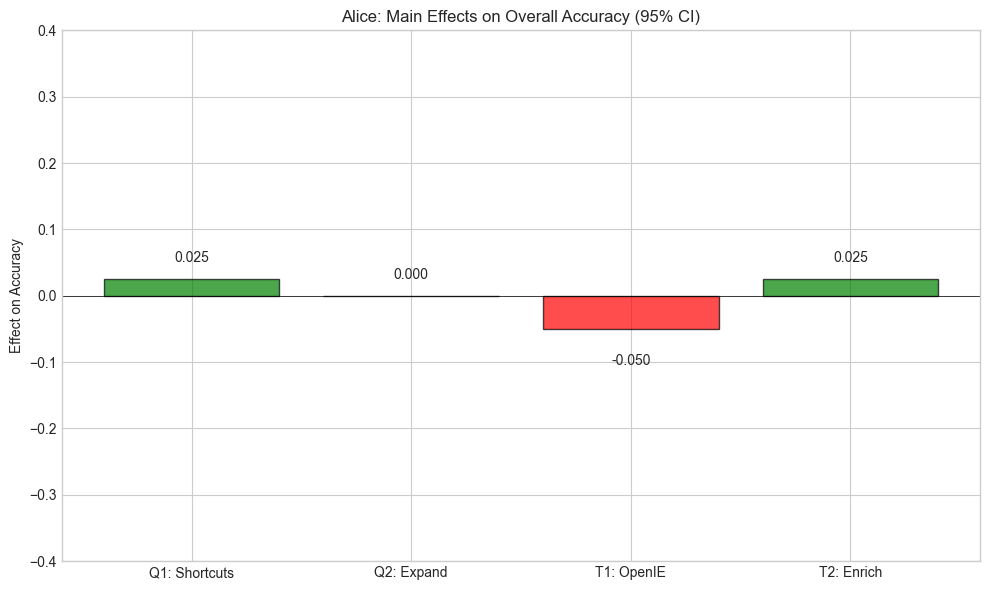

In [8]:
# Main effects bar plot - Overall (with error bars)
fig, ax = plt.subplots(figsize=(10, 6))

# Get bootstrap CIs for overall
sig_df = compute_bootstrap_ci(df, 'overall')
effects = [all_effects['overall'][f] for f in FACTORS]
errors = [(sig_df[sig_df['Effect'] == f]['Estimate'].values[0] - sig_df[sig_df['Effect'] == f]['CI_Low'].values[0],
           sig_df[sig_df['Effect'] == f]['CI_High'].values[0] - sig_df[sig_df['Effect'] == f]['Estimate'].values[0]) 
          for f in FACTORS]
errors = np.array(errors).T

colors = ['green' if e > 0 else 'red' for e in effects]

bars = ax.bar(FACTOR_LABELS, effects, color=colors, alpha=0.7, edgecolor='black', 
              yerr=errors, capsize=5, error_kw={'linewidth': 1.5})
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel('Effect on Accuracy')
ax.set_title(f'{DATASET_NAME}: Main Effects on Overall Accuracy (95% CI)')
ax.set_ylim(-0.4, 0.4)

for bar, eff in zip(bars, effects):
    ax.annotate(f'{eff:.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 10 if eff >= 0 else -18), textcoords='offset points',
                ha='center', va='bottom' if eff >= 0 else 'top')

plt.tight_layout()
plt.savefig(f'{DATASET_NAME.lower()}_main_effects.png', dpi=150)
plt.show()

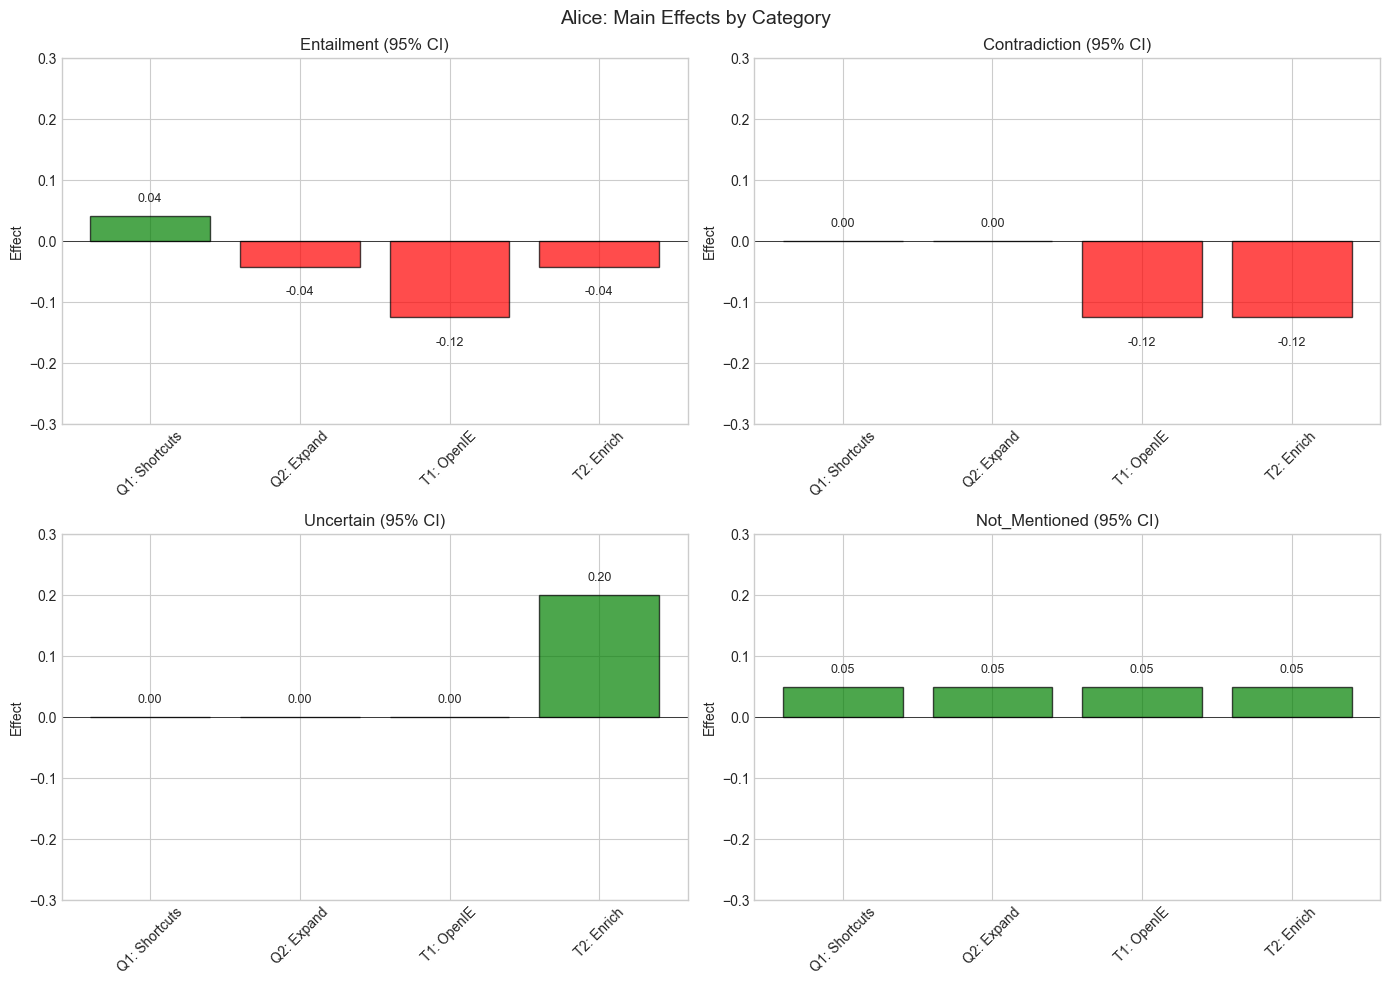

In [17]:
# Main effects by category (with error bars)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, cat in enumerate(CATEGORIES):
    ax = axes[idx // 2, idx % 2]
    
    # Get bootstrap CIs for this category
    sig_df = compute_bootstrap_ci(df, cat)
    effects = [all_effects[cat][f] for f in FACTORS]
    errors = [(sig_df[sig_df['Effect'] == f]['Estimate'].values[0] - sig_df[sig_df['Effect'] == f]['CI_Low'].values[0],
               sig_df[sig_df['Effect'] == f]['CI_High'].values[0] - sig_df[sig_df['Effect'] == f]['Estimate'].values[0]) 
              for f in FACTORS]
    errors = np.array(errors).T
    
    colors = ['green' if e > 0 else 'red' for e in effects]
    
    bars = ax.bar(
        FACTOR_LABELS,
        effects,
        color=colors,
        alpha=0.7,
        edgecolor='black',
        yerr=errors,
        capsize=4,
        error_kw={'linewidth': 1.2}
    )
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_ylabel('Effect')
    ax.set_title(f'{cat.title()} (95% CI)')
    ax.set_ylim(-0.3, 0.3)
    ax.tick_params(axis='x', rotation=45)
    
    for bar, eff in zip(bars, effects):
        ax.annotate(
            f'{eff:.2f}',
            xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
            xytext=(0, 8 if eff >= 0 else -14),
            textcoords='offset points',
            ha='center',
            va='bottom' if eff >= 0 else 'top',
            fontsize=9
        )

plt.suptitle(f'{DATASET_NAME}: Main Effects by Category', fontsize=14)
plt.tight_layout()
plt.savefig(f'{DATASET_NAME.lower()}_effects_by_category.png', dpi=150)
plt.show()

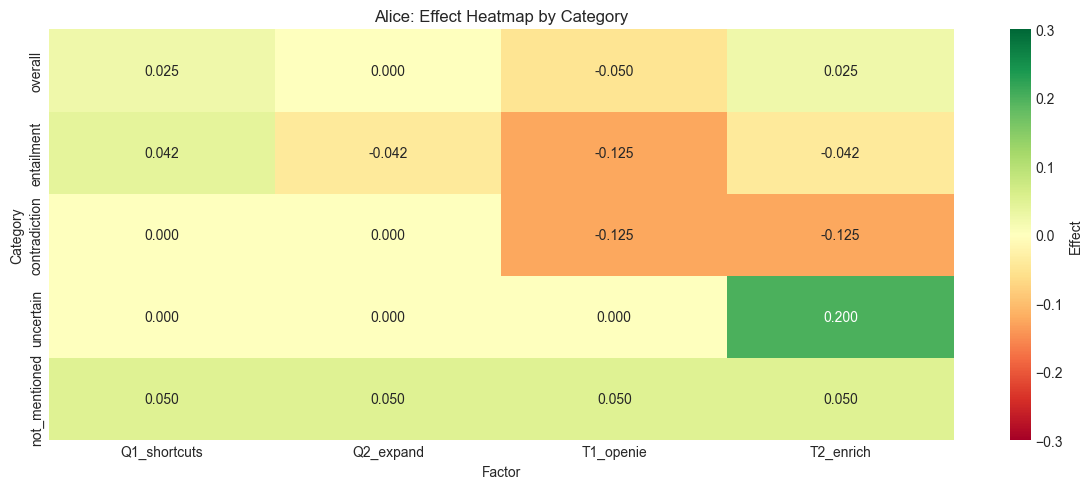

In [10]:
# Heatmap of effects
fig, ax = plt.subplots(figsize=(12, 5))

effect_matrix = pd.DataFrame({cat: {f: all_effects[cat][f] for f in FACTORS} for cat in ['overall'] + CATEGORIES}).T

sns.heatmap(effect_matrix, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            vmin=-0.3, vmax=0.3, ax=ax, cbar_kws={'label': 'Effect'})
ax.set_title(f'{DATASET_NAME}: Effect Heatmap by Category')
ax.set_xlabel('Factor')
ax.set_ylabel('Category')

plt.tight_layout()
plt.savefig(f'{DATASET_NAME.lower()}_heatmap.png', dpi=150)
plt.show()

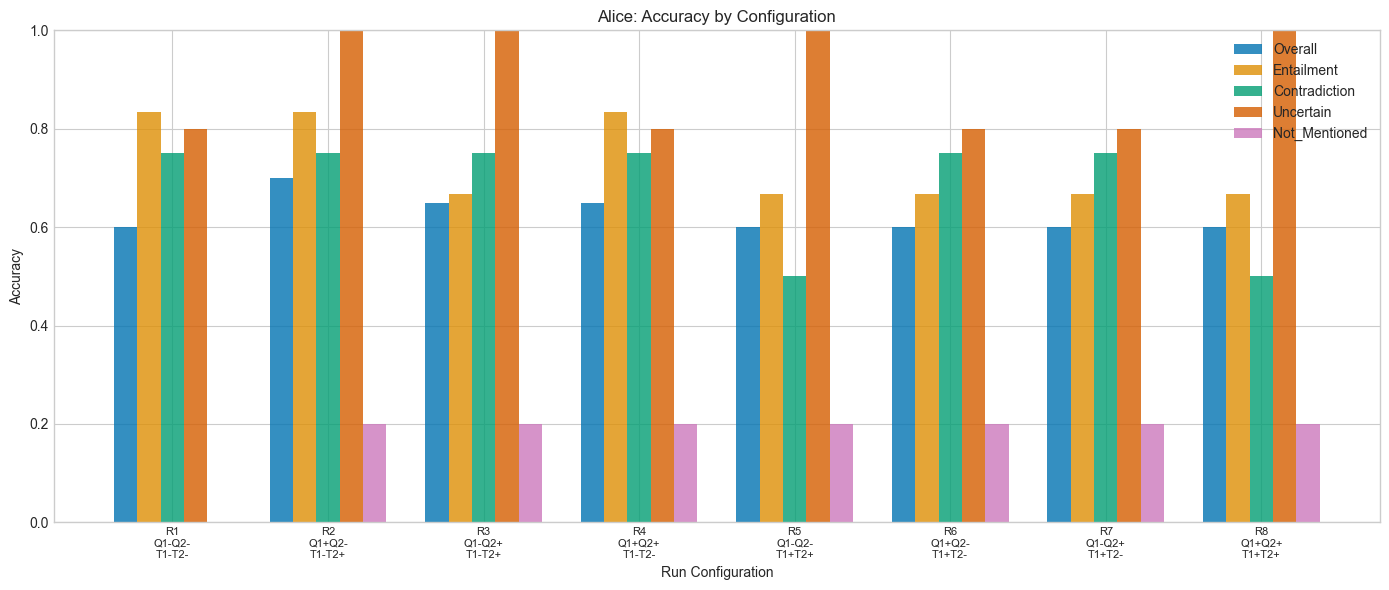

In [11]:
# Accuracy by configuration
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(8)
width = 0.15

for i, cat in enumerate(['overall'] + CATEGORIES):
    label = 'Overall' if cat == 'overall' else cat.title()
    ax.bar(x + i*width - 2*width, df[cat], width, label=label, alpha=0.8)

ax.set_ylabel('Accuracy')
ax.set_xlabel('Run Configuration')
ax.set_title(f'{DATASET_NAME}: Accuracy by Configuration')
ax.set_xticks(x)
labels = [f"R{int(r['Run'])}\nQ1{'+' if r['Q1_shortcuts']==1 else '-'}Q2{'+' if r['Q2_expand']==1 else '-'}\nT1{'+' if r['T1_openie']==1 else '-'}T2{'+' if r['T2_enrich']==1 else '-'}" for _, r in df.iterrows()]
ax.set_xticklabels(labels, fontsize=8)
ax.legend(loc='upper right')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f'{DATASET_NAME.lower()}_accuracy_by_config.png', dpi=150)
plt.show()

## 5. Summary Statistics

In [12]:
print("="*60)
print(f"SUMMARY - {DATASET_NAME}")
print("="*60)

# Best/worst configurations
best_idx = df['overall'].idxmax()
worst_idx = df['overall'].idxmin()

print(f"\nOverall Accuracy: Mean={df['overall'].mean():.3f}, Std={df['overall'].std():.3f}")
print(f"\nBest Config:  Run {int(df.loc[best_idx, 'Run'])} (Acc={df.loc[best_idx, 'overall']:.3f})")
print(f"  Q1={'+' if df.loc[best_idx, 'Q1_shortcuts']==1 else '-'}, Q2={'+' if df.loc[best_idx, 'Q2_expand']==1 else '-'}, T1={'+' if df.loc[best_idx, 'T1_openie']==1 else '-'}, T2={'+' if df.loc[best_idx, 'T2_enrich']==1 else '-'}")
print(f"\nWorst Config: Run {int(df.loc[worst_idx, 'Run'])} (Acc={df.loc[worst_idx, 'overall']:.3f})")
print(f"  Q1={'+' if df.loc[worst_idx, 'Q1_shortcuts']==1 else '-'}, Q2={'+' if df.loc[worst_idx, 'Q2_expand']==1 else '-'}, T1={'+' if df.loc[worst_idx, 'T1_openie']==1 else '-'}, T2={'+' if df.loc[worst_idx, 'T2_enrich']==1 else '-'}")

# Category difficulty
print("\nCategory Difficulty (lower = harder):")
cat_means = {cat: df[cat].mean() for cat in CATEGORIES}
for i, (cat, mean) in enumerate(sorted(cat_means.items(), key=lambda x: x[1]), 1):
    print(f"  {i}. {cat.title()}: {mean:.3f}")

SUMMARY - Alice

Overall Accuracy: Mean=0.625, Std=0.038

Best Config:  Run 2 (Acc=0.700)
  Q1=+, Q2=-, T1=-, T2=+

Worst Config: Run 1 (Acc=0.600)
  Q1=-, Q2=-, T1=-, T2=-

Category Difficulty (lower = harder):
  1. Not_Mentioned: 0.175
  2. Contradiction: 0.688
  3. Entailment: 0.729
  4. Uncertain: 0.900


## 6. LaTeX Tables

In [13]:
# Results table
print(f"% LaTeX Table: {DATASET_NAME} Results")
print("\\begin{table}[t]")
print("\\centering")
print(f"\\caption{{{DATASET_NAME} accuracy (\\%) by configuration. This dataset contains modal language.}}")
print(f"\\label{{tab:{DATASET_NAME.lower()}_results}}")
print("\\begin{tabular}{c cccc | c cccc}")
print("\\toprule")
print("Run & $Q_1$ & $Q_2$ & $T_1$ & $T_2$ & Overall & Entail & Contra & Uncert & NotMent \\\\")
print("\\midrule")

for _, row in df.iterrows():
    print(f"{int(row['Run'])} & ${'+' if row['Q1_shortcuts']==1 else '-'}$ & ${'+' if row['Q2_expand']==1 else '-'}$ & "
          f"${'+' if row['T1_openie']==1 else '-'}$ & ${'+' if row['T2_enrich']==1 else '-'}$ & "
          f"{row['overall']*100:.1f} & {row['entailment']*100:.1f} & {row['contradiction']*100:.1f} & "
          f"{row['uncertain']*100:.1f} & {row['not_mentioned']*100:.1f} \\\\")

print("\\bottomrule")
print("\\end{tabular}")
print("\\end{table}")

% LaTeX Table: Alice Results
\begin{table}[t]
\centering
\caption{Alice accuracy (\%) by configuration. This dataset contains modal language.}
\label{tab:alice_results}
\begin{tabular}{c cccc | c cccc}
\toprule
Run & $Q_1$ & $Q_2$ & $T_1$ & $T_2$ & Overall & Entail & Contra & Uncert & NotMent \\
\midrule
1 & $-$ & $-$ & $-$ & $-$ & 60.0 & 83.3 & 75.0 & 80.0 & 0.0 \\
2 & $+$ & $-$ & $-$ & $+$ & 70.0 & 83.3 & 75.0 & 100.0 & 20.0 \\
3 & $-$ & $+$ & $-$ & $+$ & 65.0 & 66.7 & 75.0 & 100.0 & 20.0 \\
4 & $+$ & $+$ & $-$ & $-$ & 65.0 & 83.3 & 75.0 & 80.0 & 20.0 \\
5 & $-$ & $-$ & $+$ & $+$ & 60.0 & 66.7 & 50.0 & 100.0 & 20.0 \\
6 & $+$ & $-$ & $+$ & $-$ & 60.0 & 66.7 & 75.0 & 80.0 & 20.0 \\
7 & $-$ & $+$ & $+$ & $-$ & 60.0 & 66.7 & 75.0 & 80.0 & 20.0 \\
8 & $+$ & $+$ & $+$ & $+$ & 60.0 & 66.7 & 50.0 & 100.0 & 20.0 \\
\bottomrule
\end{tabular}
\end{table}


In [14]:
# Effects table
print(f"\n% LaTeX Table: {DATASET_NAME} Main Effects")
print("\\begin{table}[t]")
print("\\centering")
print(f"\\caption{{{DATASET_NAME} main effects (percentage points) by category.}}")
print(f"\\label{{tab:{DATASET_NAME.lower()}_effects}}")
print("\\begin{tabular}{l ccccc}")
print("\\toprule")
print("Factor & Overall & Entail & Contra & Uncert & NotMent \\\\")
print("\\midrule")

factor_latex = ['$Q_1$: Shortcuts', '$Q_2$: Expand', '$T_1$: OpenIE', '$T_2$: Enrich']
for factor, name in zip(FACTORS, factor_latex):
    vals = [all_effects['overall'][factor]] + [all_effects[cat][factor] for cat in CATEGORIES]
    formatted = [f"\\textbf{{{v*100:+.1f}}}" if abs(v) > 0.05 else f"{v*100:+.1f}" for v in vals]
    print(f"{name} & {' & '.join(formatted)} \\\\")

print("\\bottomrule")
print("\\end{tabular}")
print("\\end{table}")


% LaTeX Table: Alice Main Effects
\begin{table}[t]
\centering
\caption{Alice main effects (percentage points) by category.}
\label{tab:alice_effects}
\begin{tabular}{l ccccc}
\toprule
Factor & Overall & Entail & Contra & Uncert & NotMent \\
\midrule
$Q_1$: Shortcuts & +2.5 & +4.2 & +0.0 & +0.0 & +5.0 \\
$Q_2$: Expand & +0.0 & -4.2 & +0.0 & +0.0 & +5.0 \\
$T_1$: OpenIE & -5.0 & \textbf{-12.5} & \textbf{-12.5} & +0.0 & +5.0 \\
$T_2$: Enrich & +2.5 & -4.2 & \textbf{-12.5} & \textbf{+20.0} & +5.0 \\
\bottomrule
\end{tabular}
\end{table}


In [15]:
# Save results
df.to_csv(f'{DATASET_NAME.lower()}_results.csv', index=False)
pd.DataFrame(all_effects).to_csv(f'{DATASET_NAME.lower()}_effects.csv')
print(f"\nSaved: {DATASET_NAME.lower()}_results.csv, {DATASET_NAME.lower()}_effects.csv")


Saved: alice_results.csv, alice_effects.csv
